# Making a VLA fast, and trying to make it faster with my own phone video

SmolVLA (`HuggingFaceVLA/smolvla_libero`) on LIBERO-Spatial, Colab T4. Two parts:

1. **Speed.** Profile the policy, then cut model time per control step from 842 ms to about 17 ms with no training.
2. **My data.** 20 phone-recorded tasks, no action labels, used to distil the 10-step action sampler into a 1-step student.
   It made the student closer to the teacher offline and worse in simulation; a control run and one more measurement explain why.

The README has the summary and the discussion. Each code cell below is followed by the result from my run.
The long LIBERO evaluations are listed as commands; their outputs are in `results/`.

## 0. Setup

In [1]:
!nvidia-smi --query-gpu=name --format=csv,noheader
!pip -q install "lerobot[libero,smolvla] @ git+https://github.com/huggingface/lerobot.git@6e1fa4faf2a42927d463591aebaa0f62c2e654b7"

Tesla T4


I keep the repository in Google Drive so that models, frames and results survive a disconnected session.
Set `REPO` to the folder that holds this notebook's repository.

In [2]:
from google.colab import drive
import os, shutil, pathlib

drive.mount("/content/drive")
REPO = "/content/drive/MyDrive/vla_project"
os.environ["HF_HOME"] = f"{REPO}/hf_cache"  # model downloads persist across sessions
os.environ["MUJOCO_GL"] = "egl"             # headless rendering

# LIBERO asks for a dataset folder on first import; reuse the answer saved from the first session.
cfg, saved = pathlib.Path("/root/.libero/config.yaml"), pathlib.Path(REPO) / "libero_config.yaml"
if saved.exists():
    cfg.parent.mkdir(exist_ok=True)
    shutil.copy(saved, cfg)
elif cfg.exists():
    shutil.copy(cfg, saved)

%cd $REPO

Mounted at /content/drive
/content/drive/MyDrive/vla_project


## 1. Where does the time go?

A first LIBERO episode ran at about 1.3 s per control step, and the robot needs 20 decisions per second.
Below, the model is timed alone on random inputs; latency does not depend on image content.

In [3]:
import time
import numpy as np, torch
from lerobot.policies.smolvla.modeling_smolvla import SmolVLAPolicy

dev = "cuda"
policy = SmolVLAPolicy.from_pretrained("HuggingFaceVLA/smolvla_libero").eval()

images = [torch.rand(1, 3, 512, 512, device=dev) * 2 - 1 for _ in range(2)]  # two cameras
masks = [torch.ones(1, dtype=torch.bool, device=dev)] * 2
lang = torch.randint(0, 1000, (1, 24), device=dev)
lang_mask = torch.ones(1, 24, dtype=torch.bool, device=dev)
state = torch.zeros(1, 32, device=dev)

def one_call():
    torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.no_grad():
        policy.model.sample_actions(images, masks, lang, lang_mask, state)
    torch.cuda.synchronize()
    return (time.perf_counter() - start) * 1000

for _ in range(3):
    one_call()  # warm-up
print(f"one model call: {np.median([one_call() for _ in range(10)]):.0f} ms")

Loading  HuggingFaceTB/SmolVLM2-500M-Instruct weights ...


one model call: 863 ms


Split one call into its three stages: the vision encoder (two images), the prefix pass over images, text and state,
and the flow-matching loop that turns noise into an action chunk (10 denoising steps by default).

In [4]:
vlm = policy.model.vlm_with_expert
spent = {"vision": 0.0, "prefix": 0.0, "denoise": 0.0}

def timed(fn, part_of):
    def wrapper(*args, **kwargs):
        torch.cuda.synchronize()
        start = time.perf_counter()
        out = fn(*args, **kwargs)
        torch.cuda.synchronize()
        spent[part_of(kwargs)] += (time.perf_counter() - start) * 1000
        return out
    return wrapper

# Run this cell once: it wraps the functions in place.
vlm.embed_image = timed(vlm.embed_image, lambda kw: "vision")
vlm.forward = timed(vlm.forward, lambda kw: "prefix" if kw.get("past_key_values") is None else "denoise")

N = 10
for _ in range(N):
    one_call()
for part, ms in spent.items():
    print(f"{part:8s} {ms / N:5.0f} ms")
print("parameter dtypes:", {p.dtype for p in policy.parameters()})

vision     217 ms
prefix      71 ms
denoise    589 ms
parameter dtypes: {torch.bfloat16, torch.float32}


**My run:** one call 863 ms; vision 217 ms, prefix 71 ms, denoising 589 ms. The vision-language model is stored in `bfloat16`,
which the T4 has no fast path for.

In [5]:
vlm_model = policy.model.vlm_with_expert.vlm
for dtype in [torch.bfloat16, torch.float16, torch.float32]:
    vlm_model.to(dtype)
    for _ in range(3):
        one_call()
    spent.update(dict.fromkeys(spent, 0.0))
    total = np.median([one_call() for _ in range(N)])
    print(f"{str(dtype):15s} total {total:4.0f} ms   " + "  ".join(f"{k} {v / N:.0f}" for k, v in spent.items()))

torch.bfloat16  total  884 ms   vision 213  prefix 76  denoise 639
torch.float16   total  683 ms   vision 26  prefix 69  denoise 640
torch.float32   total  784 ms   vision 143  prefix 59  denoise 568


**My run:**

| dtype | vision | total |
|---|---|---|
| bfloat16 (as shipped) | 213 ms | 884 ms |
| float32 | 143 ms | 784 ms |
| float16 | **26 ms** | **683 ms** |

Faster is only useful if the output stays the same. Same input and same starting noise, compared with float32:

In [6]:
torch.manual_seed(0)
noise = torch.randn(1, 50, 32, device=dev)

def actions(dtype):
    vlm_model.to(dtype)
    with torch.no_grad():
        out = policy.model.sample_actions(images, masks, lang, lang_mask, state, noise=noise.clone())
    return out[0, :, :7].float()

reference = actions(torch.float32)
for dtype in [torch.bfloat16, torch.float16]:
    a = actions(dtype)
    print(f"{str(dtype):15s} relative error {((a - reference).norm() / reference.norm()).item():.4f}   NaN: {a.isnan().any().item()}")
vlm_model.to(torch.float16);

torch.bfloat16  relative error 0.0306   NaN: False
torch.float16   relative error 0.0025   NaN: False


**My run:** bfloat16 0.031, float16 0.0025 (0.014 and 0.003 in an earlier session). float16 is both faster and closer to full precision. Everything below uses it.

Denoising is now 90% of the call. Fewer denoising steps:

In [7]:
for steps in [10, 5, 3, 2, 1]:
    policy.config.num_steps = steps
    print(f"{steps:2d} steps: {np.median([one_call() for _ in range(10)]):.0f} ms")
policy.config.num_steps = 10

10 steps: 683 ms
 5 steps: 395 ms
 3 steps: 344 ms
 2 steps: 207 ms
 1 steps: 149 ms


**My run:** 10 steps 683 ms, 5 steps 395, 3 steps 344, 2 steps 207, 1 step 149: about 60 ms per denoising step.

The last lever is how often the model runs at all. The checkpoint re-plans at every control step
(`n_action_steps=1`) although it predicts 50 actions each time. Executing 10 of them before re-planning
divides the model time per control step by 10.

All configurations in one session, so that the numbers are comparable:

In [8]:
configs = [  # label, dtype, denoising steps, actions executed per model call
    ("as shipped: bfloat16, 10 steps, re-plan every step", torch.bfloat16, 10, 1),
    ("float16, 10 steps, re-plan every step", torch.float16, 10, 1),
    ("float16, 1 step, re-plan every step", torch.float16, 1, 1),
    ("float16, 1 step, re-plan every 10 steps", torch.float16, 1, 10),
]
for label, dtype, steps, chunk in configs:
    vlm_model.to(dtype)
    policy.config.num_steps = steps
    for _ in range(3):
        one_call()
    ms = np.median([one_call() for _ in range(20)])
    print(f"{label:50s} {ms:5.0f} ms per call   {ms / chunk:6.1f} ms per control step")
vlm_model.to(torch.float16)
policy.config.num_steps = 10

as shipped: bfloat16, 10 steps, re-plan every step   854 ms per call    854.1 ms per control step
float16, 10 steps, re-plan every step                704 ms per call    704.1 ms per control step
float16, 1 step, re-plan every step                  193 ms per call    192.8 ms per control step
float16, 1 step, re-plan every 10 steps              153 ms per call     15.3 ms per control step


**My run:** as shipped 854 ms per call; float16 with 10 steps 704 ms; float16 with 1 step 193 ms and 153 ms in the
last two rows. Those two rows run the same computation (how many actions are executed does not change the call),
so the gap shows the measurement noise. Per control step: 854 ms as shipped, about 15 ms in the fast setting.

## 2. Does it still work? Evaluation in LIBERO

`fast_eval.py` wraps `lerobot-eval`: float16 vision-language model, optional student weights, optional capture of
model inputs, and the median model time measured inside the simulation. Every configuration was run on the 10
LIBERO-Spatial tasks, 4 episodes each. Each run takes 1 to 2 hours on a T4, mostly simulator time
(about 0.5 s per control step outside the model).

In [ ]:
COMMON = ("--policy.path=HuggingFaceVLA/smolvla_libero --env.type=libero --env.task=libero_spatial "
          "--eval.batch_size=1 --eval.n_episodes=4")
SHOW = '2>&1 | grep -E "fast_eval|Success rate|Error"'

# Reference: 10 denoising steps, re-plan every step.
!python fast_eval.py --policy.num_steps=10 --policy.n_action_steps=1 {COMMON} --output_dir=runs/reference_10step {SHOW}

# Fast: 1 step, re-plan every 10 steps. --capture also saves the model inputs, used as simulator data in section 4.
!python fast_eval.py --policy.num_steps=1 --policy.n_action_steps=10 --capture=data/sim.npz {COMMON} --output_dir=runs/fast_1step_chunk10 {SHOW}

**My run:** reference 28/40 (70%) at 586 ms per call; fast 30/40 (75%) at 172 ms per call, which is 17 ms per control step.
No loss is visible at this sample size. Others report about 79% for this checkpoint, so the reference is in range.

A lesson from earlier runs with 1 episode per task: the first initial state of every task is easy, so 10-episode runs
gave 10/10 for the fast setting and 2/10 for a student, which 40 episodes corrected to 75% and 37.5%.
Those early runs are in `results/early/`.

## 3. My data

20 one-handed tasks (cup, bowl, fork, banana, ...), each filmed twice with a phone: from above (`front`) and from the
side at an angle (`close`). The side view looks more like LIBERO's front camera and the top view more like its wrist
camera, so `close` feeds camera 1 and `front` camera 2. Instructions are in `data/tasks.txt`.

From each clip, 24 frames are sampled at matching times, centre-cropped to a square and resized to 256 px.

In [10]:
import re
import cv2

def read_tasks(path):
    tasks = {}
    for line in pathlib.Path(path).read_text().splitlines():
        m = re.match(r"\s*(\d+)\s*[:.\-]\s*(.+)", line)
        if m:
            tasks[int(m.group(1))] = m.group(2).strip()
    return tasks

def read_frames(path, n=24, size=256):
    cap = cv2.VideoCapture(str(path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames = []
    for i in np.linspace(0, total - 1, n).astype(int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, f = cap.read()
        if not ok:
            continue
        h, w = f.shape[:2]
        s = min(h, w)
        f = f[(h - s) // 2:(h - s) // 2 + s, (w - s) // 2:(w - s) // 2 + s]
        frames.append(cv2.cvtColor(cv2.resize(f, (size, size), interpolation=cv2.INTER_AREA), cv2.COLOR_BGR2RGB))
    cap.release()
    return frames

def save_phone_npz(front, close, task_id, tasks, path="data/phone.npz"):
    np.savez_compressed(path, front=np.stack(front), close=np.stack(close), task_id=np.array(task_id),
                        task_nums=np.array(list(tasks)), sentences=np.array(list(tasks.values())))

tasks = read_tasks("data/tasks.txt")

The raw videos are not in the repository; the sampled frames are, as JPEGs in `data/phone_frames.zip`.
Use the first cell if you have the videos, otherwise the second.

In [11]:
# From the raw videos (folder of 01_front.mp4, 01_close.mp4, ...).
VIDEOS = pathlib.Path("videos")
find = lambda num, view: next(p for p in VIDEOS.iterdir() if re.fullmatch(rf"0*{num}_{view}\.\w+", p.name, re.I))
front, close, task_id = [], [], []
for num in sorted(tasks):
    f, c = read_frames(find(num, "front")), read_frames(find(num, "close"))
    k = min(len(f), len(c))
    front += f[:k]; close += c[:k]; task_id += [num] * k
save_phone_npz(front, close, task_id, tasks)

# Export the frames for the repository.
out = pathlib.Path("data/phone_frames"); out.mkdir(parents=True, exist_ok=True)
count = {}
for i, t in enumerate(task_id):
    k = count[t] = count.get(t, -1) + 1
    for view, frames in (("front", front), ("close", close)):
        cv2.imwrite(str(out / f"{t:02d}_{k:02d}_{view}.jpg"), cv2.cvtColor(frames[i], cv2.COLOR_RGB2BGR),
                    [cv2.IMWRITE_JPEG_QUALITY, 90])
shutil.make_archive("data/phone_frames", "zip", "data/phone_frames")  # one file is easier to upload
print(len(task_id), "frame pairs from", len(set(task_id)), "tasks")

480 frame pairs from 20 tasks


In [ ]:
# From the JPEGs in the repository (JPEG compression makes results differ slightly from mine).
if not pathlib.Path("data/phone_frames").exists():
    shutil.unpack_archive("data/phone_frames.zip", "data/phone_frames")
files = sorted(pathlib.Path("data/phone_frames").glob("*_front.jpg"))
load = lambda p: cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
save_phone_npz([load(p) for p in files], [load(str(p).replace("_front", "_close")) for p in files],
               [int(p.name[:2]) for p in files], tasks)
print(len(files), "frame pairs")

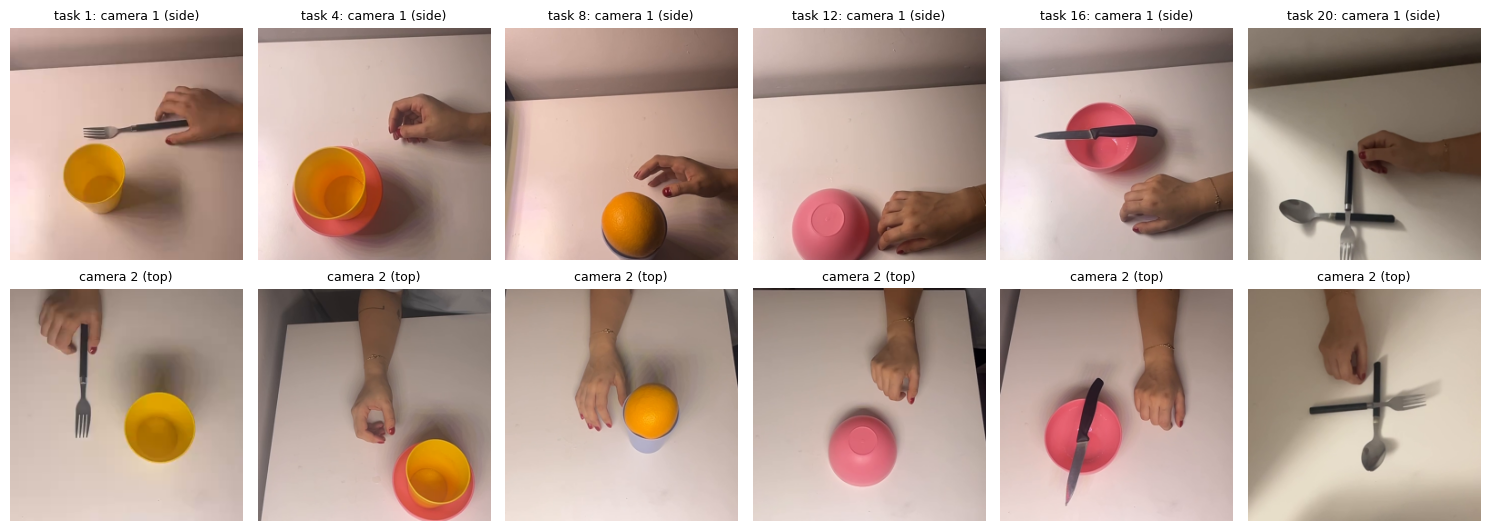

In [17]:
import matplotlib.pyplot as plt

d = np.load("data/phone.npz")
picks = np.linspace(0, len(d["front"]) - 1, 6).astype(int)
fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for col, i in enumerate(picks):
    axes[0, col].imshow(d["close"][i]); axes[0, col].set_title(f"task {d['task_id'][i]}: camera 1 (side)", fontsize=9)
    axes[1, col].imshow(d["front"][i]); axes[1, col].set_title("camera 2 (top)", fontsize=9)
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.savefig("media/phone_frames.png", dpi=80)
plt.show()

## 4. Label-free step distillation

The phone video has no action labels. The 10-step model does not need them: it is the teacher, and its answer on my
frames is the target. A copy of the action expert (97M parameters; vision and language frozen) is trained to give
the same answer in **one** denoising step, from the same starting noise. Tasks 17 to 20 are held out.
State is set to zero, which after LeRobot's normalisation is the dataset mean.

In [12]:
from transformers import AutoTokenizer
from distill import Distiller, phone_dataset, sim_dataset

policy = SmolVLAPolicy.from_pretrained("HuggingFaceVLA/smolvla_libero").eval()
policy.model.vlm_with_expert.vlm.to(torch.float16)
tokenizer = AutoTokenizer.from_pretrained(policy.config.vlm_model_name)
D = Distiller(policy, tokenizer)
phone = phone_dataset("data/phone.npz", tokenizer)

Loading  HuggingFaceTB/SmolVLM2-500M-Instruct weights ...


First, a check that the teacher reacts to my frames at all (relative change of the action chunk):

In [18]:
idx = np.arange(12, len(phone["task"]), 24)[:8]  # middle frame of the first 8 tasks
torch.manual_seed(0)
noise = torch.randn(1, 50, 32, device=dev).expand(len(idx), -1, -1)
rel = lambda a, b: ((a - b)[..., :7].norm() / b[..., :7].norm()).item()
with torch.no_grad():
    teacher = D.run(phone, idx, noise, 10)
    other_text = dict(phone, tokens=phone["tokens"].copy())
    other_text["tokens"][idx] = phone["tokens"][idx][::-1]  # each frame gets another task's instruction
    print(f"other instruction:  {rel(D.run(other_text, idx, noise, 10), teacher):.3f}")
    swapped = dict(phone, cam1=phone["cam2"], cam2=phone["cam1"])
    print(f"cameras swapped:    {rel(D.run(swapped, idx, noise, 10), teacher):.3f}")
    for steps in [5, 3, 2, 1]:
        print(f"{steps} steps vs 10:      {rel(D.run(phone, idx, noise, steps), teacher):.3f}")

other instruction:  0.657
cameras swapped:    0.406
5 steps vs 10:      0.191
3 steps vs 10:      0.331
2 steps vs 10:      0.443
1 steps vs 10:      0.757


**My run:** changing the instruction moves the output by 0.66 and swapping the cameras by 0.41, so the teacher does read
my frames and sentences. One step is 0.76 away from ten.

In [ ]:
phone_teacher = D.teacher_targets(phone)  # 480 frames x 4 starting noises, about 4 minutes
torch.save(phone_teacher, "data/teacher_phone.pt")
D.train(phone, phone_teacher, test_tasks=list(range(17, 21)), save_to="data/student_phone_1step.pt")  # about 13 minutes

**My run:** on the held-out tasks the 1-step distance to the teacher fell from 0.67 to 0.35, level with the untrained
model at 2 steps. It stopped improving after about 500 of 1000 steps.

**Control.** If the student fails in simulation, is it the phone video or the method? The same recipe on frames
captured from LIBERO itself (`data/sim.npz`, from the fast evaluation in section 2), holding out tasks 8 and 9:

In [13]:
sim = sim_dataset("data/sim.npz")
row = sim["tokens"][0]
print("LIBERO instruction:", repr(tokenizer.decode(row[row >= 0])))  # same format as the phone instructions

LIBERO instruction: 'pick up the black bowl between the plate and the ramekin and place it on the plate\n'


In [ ]:
sim_teacher = D.teacher_targets(sim)
torch.save(sim_teacher, "data/teacher_sim.pt")
D.train(sim, sim_teacher, test_tasks=[8, 9], save_to="data/student_sim_1step.pt")

**My run:** held-out distance 0.49 to 0.28.

In [ ]:
for name in ["student_sim_1step", "student_phone_1step"]:
    !python fast_eval.py --student=data/{name}.pt --policy.num_steps=1 --policy.n_action_steps=10 {COMMON} --output_dir=runs/{name}_chunk10 {SHOW}

**My run:** student (sim frames) 21/40 (52.5%), student (phone video) 15/40 (37.5%), against 30/40 for the
untrained model in the same setting. Both students are worse; the phone student clearly so. Being closer to the
teacher offline did not mean better behaviour. In the videos the students reach the bowl but hesitate and jitter
at the grasp.

The sim student's held-out tasks 8 and 9 scored 4/8 and its training tasks 17/32, so it was not helped by having
seen those scenes.

## 5. Why the students fail

For flow matching, one Euler step from noise returns approximately the *mean* action for the observation, which
barely depends on the starting noise. Ten steps return a *sample*, which does. Distillation trains the 1-step model
to reproduce samples. Test: the same input with 6 different starting noises; how much do the answers differ?

In [14]:
frames_of = lambda ds: np.linspace(0, len(ds["task"]) - 1, 96).astype(int)
models = {"original": None, "student (sim)": "data/student_sim_1step.pt", "student (phone)": "data/student_phone_1step.pt"}
for ds_name, ds in [("LIBERO frames", sim), ("phone frames", phone)]:
    print(f"--- {ds_name} ---")
    D.load_weights(None)
    print(f"{'teacher, 10 steps':24s} {D.noise_spread(ds, 10, frames_of(ds)):.3f}")
    for name, path in models.items():
        D.load_weights(path)
        print(f"{name + ', 1 step':24s} {D.noise_spread(ds, 1, frames_of(ds)):.3f}")
D.load_weights(None)

--- LIBERO frames ---
teacher, 10 steps        0.592
original, 1 step         0.149
student (sim), 1 step    0.543
student (phone), 1 step  0.576
--- phone frames ---
teacher, 10 steps        0.683
original, 1 step         0.198
student (sim), 1 step    0.538
student (phone), 1 step  0.637


**My run:**

| model | LIBERO frames | phone frames |
|---|---|---|
| original, 1 step | 0.15 | 0.20 |
| student (sim), 1 step | 0.54 | 0.54 |
| student (phone), 1 step | 0.58 | 0.64 |
| teacher, 10 steps | 0.59 | 0.68 |

The original 1-step model is nearly deterministic; both students became as noise-dependent as the teacher while
still being 0.28 to 0.35 away from it. They lost the stable mean and did not gain an accurate sample. The teacher
is just as noise-dependent and still succeeds, so noise dependence alone does not predict failure.

The phone frames give the same picture as the LIBERO frames: same ordering, similar values.

### 5b. Fix: train on the teacher's average

If the target is the problem, the student should learn the mean directly. Each frame already has 4 teacher answers
(4 starting noises) from section 4; the target becomes their average. Everything else is unchanged.

In [ ]:
for ds, saved, test_tasks, name in [(phone, "data/teacher_phone.pt", list(range(17, 21)), "student_phone_mean_1step"),
                                    (sim, "data/teacher_sim.pt", [8, 9], "student_sim_mean_1step")]:
    D.train(ds, Distiller.average_targets(torch.load(saved)), test_tasks=test_tasks, save_to=f"data/{name}.pt")
    D.load_weights(f"data/{name}.pt")
    print(f"{name}: noise spread {D.noise_spread(ds, 1, frames_of(ds)):.3f}")
D.load_weights(None)

**My run:** distance to the average target on held-out tasks 0.51 to 0.39 (phone) and 0.33 to 0.31 (LIBERO
frames), both flat after about 200 steps. Noise spread 0.19 (phone; original 0.20) and 0.16 (LIBERO; original 0.15):
the students keep the original's stability.

In [ ]:
for name in ["student_phone_mean_1step", "student_sim_mean_1step"]:
    !python fast_eval.py --student=data/{name}.pt --policy.num_steps=1 --policy.n_action_steps=10 {COMMON} --output_dir=runs/{name.replace('_1step', '')}_chunk10 {SHOW}

**My run:** both 22/40 (55%). The phone student went from 37.5% to 55% and now matches the student trained on
LIBERO's own frames, so the domain gap of the first recipe is gone. Both are still below the original 1-step model
(30/40). The LIBERO student's held-out tasks 8 and 9 scored 5/8 and its training tasks 17/32. Over all four students, 80/160 against 30/40 (Fisher's exact test, p = 0.005): distillation hurts in closed
loop even when the offline measurements barely move.

## 6. Results table and figure

| configuration | model ms per call | model ms per control step | success | 95% interval |
|---|---|---|---|---|
| 10 steps, re-plan every step | 586 | 586.0 | 28/40 (70.0%) | 55 to 82% |
| 1 step, re-plan every 10 steps | 172 | 17.2 | 30/40 (75.0%) | 60 to 86% |
| student (sim frames) | 174 | 17.4 | 21/40 (52.5%) | 37 to 67% |
| student (my phone video) | 173 | 17.3 | 15/40 (37.5%) | 24 to 53% |
wrote results/table.md and results/speed_vs_success.png


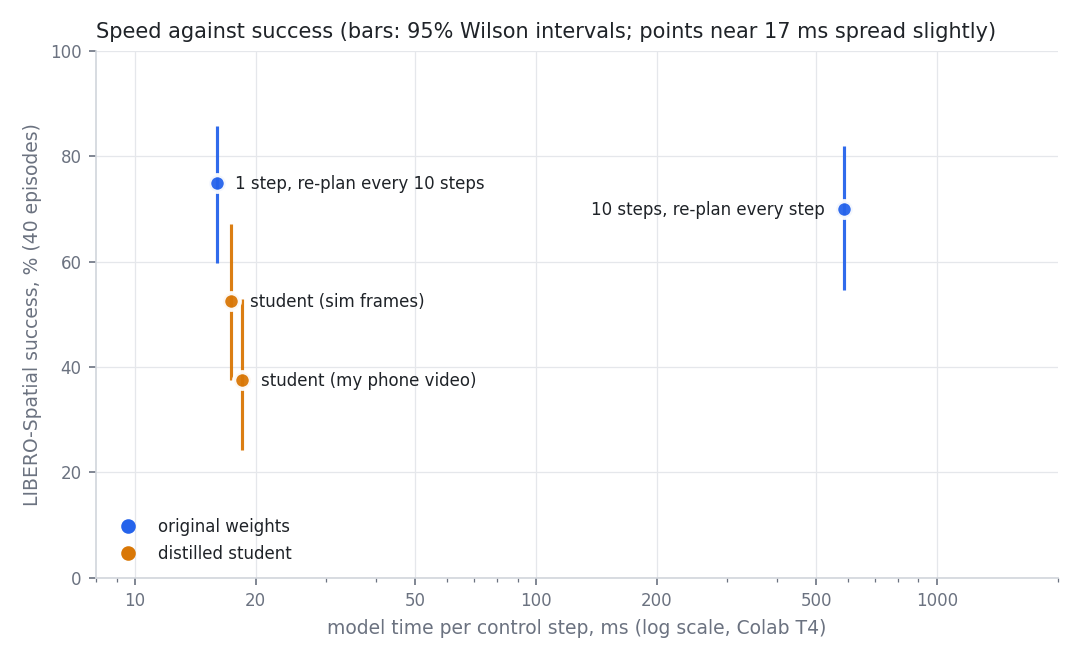

In [15]:
!python plot_results.py
from IPython.display import Image
Image("results/speed_vs_success.png")

Short GIFs of single episodes for the README (the folder names are the ones from my Drive).

In [16]:
import imageio.v3 as iio

def to_gif(mp4, gif, every=3, size=240):
    frames = [cv2.resize(f, (size, size), interpolation=cv2.INTER_AREA) for f in iio.imread(mp4)[::every]]
    iio.imwrite(gif, np.stack(frames), duration=1000 * every / 20, loop=0)  # LIBERO runs at 20 Hz

pathlib.Path("media").mkdir(exist_ok=True)
to_gif("runs/c_original_1step_chunk10_x4/videos/libero_spatial_1/eval_episode_0.mp4", "media/fast_success.gif")
to_gif("runs/c_original_10step_x4_b/videos/libero_spatial_1/eval_episode_0.mp4", "media/reference_success.gif")
to_gif("runs/c_student_phone_1step_chunk10_x4/videos/libero_spatial_0/eval_episode_0.mp4", "media/student_phone_failure.gif")